# nb04 -- Explainability of the totalVI joint model
Probe what the joint RNA-protein latent space captured. Severity is a *lens* on the
RNA-protein relationship, not the goal. All model outputs are read from the saved
`covid_totalvi.h5ad`; the trained model itself is not needed here.

## Environment setup

In [1]:
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q scanpy anndata scikit-learn
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/covid_citeseq_project')
else:
    BASE_PATH = Path('..')

print(f"Running on {'Colab' if IN_COLAB else 'local'} | BASE_PATH = {BASE_PATH}")

Mounted at /content/drive
Running on Colab | BASE_PATH = /content/drive/MyDrive/covid_citeseq_project


## Imports and config

In [11]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import balanced_accuracy_score

ADATA_PATH        = BASE_PATH / 'data' / 'processed' / 'covid_totalvi.h5ad'
GENE_MAPPING_PATH = BASE_PATH / 'results' / 'tables' / 'nb02_covid_adt_gene_mapping.csv'
RESULTS_TABLES    = BASE_PATH / 'results' / 'tables'
COUPLING_PATH     = BASE_PATH / 'src' / 'analysis' / 'coupling.py'
RESULTS_TABLES.mkdir(parents=True, exist_ok=True)

DROP_GENES = ['PDPN', 'KDR']  # zero-variance in GEX (nb02 Step 3b), removed from the 163

# --- CONFIRM THESE THREE against the validation cell below ---
SEVERITY_COL = 'Status_on_day_collection_summary'  # ASSUMPTION: severity tier column in obs
CELLTYPE_COL = 'full_clustering'                    # ASSUMPTION: cell-type annotation in obs
TIER_ORDER   = ['Healthy', 'Asymptomatic', 'Mild', 'Moderate', 'Severe', 'Critical']  # ASSUMPTION
PATIENT_COL  = 'patient_id'                          # known: totalVI batch_key in nb03

KNOWN_CONFOUND_PATIENT = 'CV0178'  # real Severe-tier coupling outlier; not excluded
N_LATENT     = 20
N_SPLITS     = 6   # GroupKFold folds over 18 patients (~3 patients/fold)
TOP_K_GENES  = 15  # pathway candidates reported per protein

## Load model outputs and gene mapping
Everything the analysis needs is already in the saved adata: `X_totalVI`,
`protein_denoised`, raw `protein_expression`, and `totalVI_normalized`.

In [3]:
adata = sc.read_h5ad(ADATA_PATH)

gene_map = pd.read_csv(GENE_MAPPING_PATH)
gene_map = gene_map[~gene_map['gene'].isin(DROP_GENES)]
adt_to_gene = dict(zip(gene_map['adt_name'], gene_map['gene']))  # protein -> matched 1:1 gene

print(adata)

AnnData object with n_obs × n_vars = 69090 × 2092
    obs: 'sample_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'full_clustering', 'initial_clustering', 'Resample', 'Collection_Day', 'Sex', 'Age_interval', 'Swab_result', 'Status', 'Smoker', 'Status_on_day_collection', 'Status_on_day_collection_summary', 'Days_from_onset', 'Site', 'time_after_LPS', 'Worst_Clinical_Status', 'Outcome', 'patient_id', '_scvi_labels', '_scvi_batch'
    var: 'feature_types', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'leiden', 'neighbors', 'pca', 'protein_names', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_totalVI', 'X_umap', 'protein_denoised', 'protein_expression'
    layers: 'counts', 'raw', 'totalVI_normalized'


## Validate structure (checkpoint-first)
Fails loudly if the three assumed columns are wrong, and prints what is actually
present so they can be corrected in one line.

In [4]:
for col in [SEVERITY_COL, CELLTYPE_COL, PATIENT_COL]:
    if col not in adata.obs:
        raise KeyError(f"{col!r} not in obs. Available columns: {list(adata.obs.columns)}")

for key in ['X_totalVI', 'protein_denoised', 'protein_expression']:
    assert key in adata.obsm, f"missing obsm[{key!r}]"
assert 'totalVI_normalized' in adata.layers, "missing layers['totalVI_normalized']"
assert 'protein_names' in adata.uns, "missing uns['protein_names']"

# lock severity ordering to the tiers actually present
present_tiers = [t for t in TIER_ORDER if t in set(adata.obs[SEVERITY_COL])]
adata.obs[SEVERITY_COL] = pd.Categorical(
    adata.obs[SEVERITY_COL], categories=present_tiers, ordered=True)

print('cells x genes      :', adata.shape)
print('latent dims        :', adata.obsm['X_totalVI'].shape[1])
print('proteins           :', len(adata.uns['protein_names']))
print('matched pairs       :', len(adt_to_gene))
print()
print('severity tiers:\n', adata.obs[SEVERITY_COL].value_counts().reindex(present_tiers))
print()
print('cell types:\n', adata.obs[CELLTYPE_COL].value_counts())
print()
print('patients:', adata.obs[PATIENT_COL].nunique())

cells x genes      : (69090, 2092)
latent dims        : 20
proteins           : 163
matched pairs       : 163

severity tiers:
 Status_on_day_collection_summary
Healthy         14145
Asymptomatic    13662
Mild            13858
Moderate        11525
Severe           7164
Critical         8736
Name: count, dtype: int64

cell types:
 full_clustering
CD4.CM                   12501
NK_16hi                   8646
CD4.Naive                 6759
B_naive                   5922
CD8.Naive                 5587
CD4.IL22                  5488
CD8.TE                    2857
CD83_CD14_mono            2505
CD8.EM                    2431
CD4.Tfh                   2419
Platelets                 2245
gdT                       1897
MAIT                      1763
NK_56hi                   1182
RBC                       1079
B_switched_memory         1062
B_immature                 724
B_non-switched_memory      422
DC3                        393
NKT                        366
B_exhausted                268


## Step 1 -- Latent sanity check (UMAP)
Gate for everything below: the latent space must show clean cell-type separation.
If cell types don't separate, the joint space is not capturing biology and the
downstream probes are meaningless.

In [5]:
sc.pp.neighbors(adata, use_rep='X_totalVI', n_neighbors=15)
sc.tl.umap(adata)

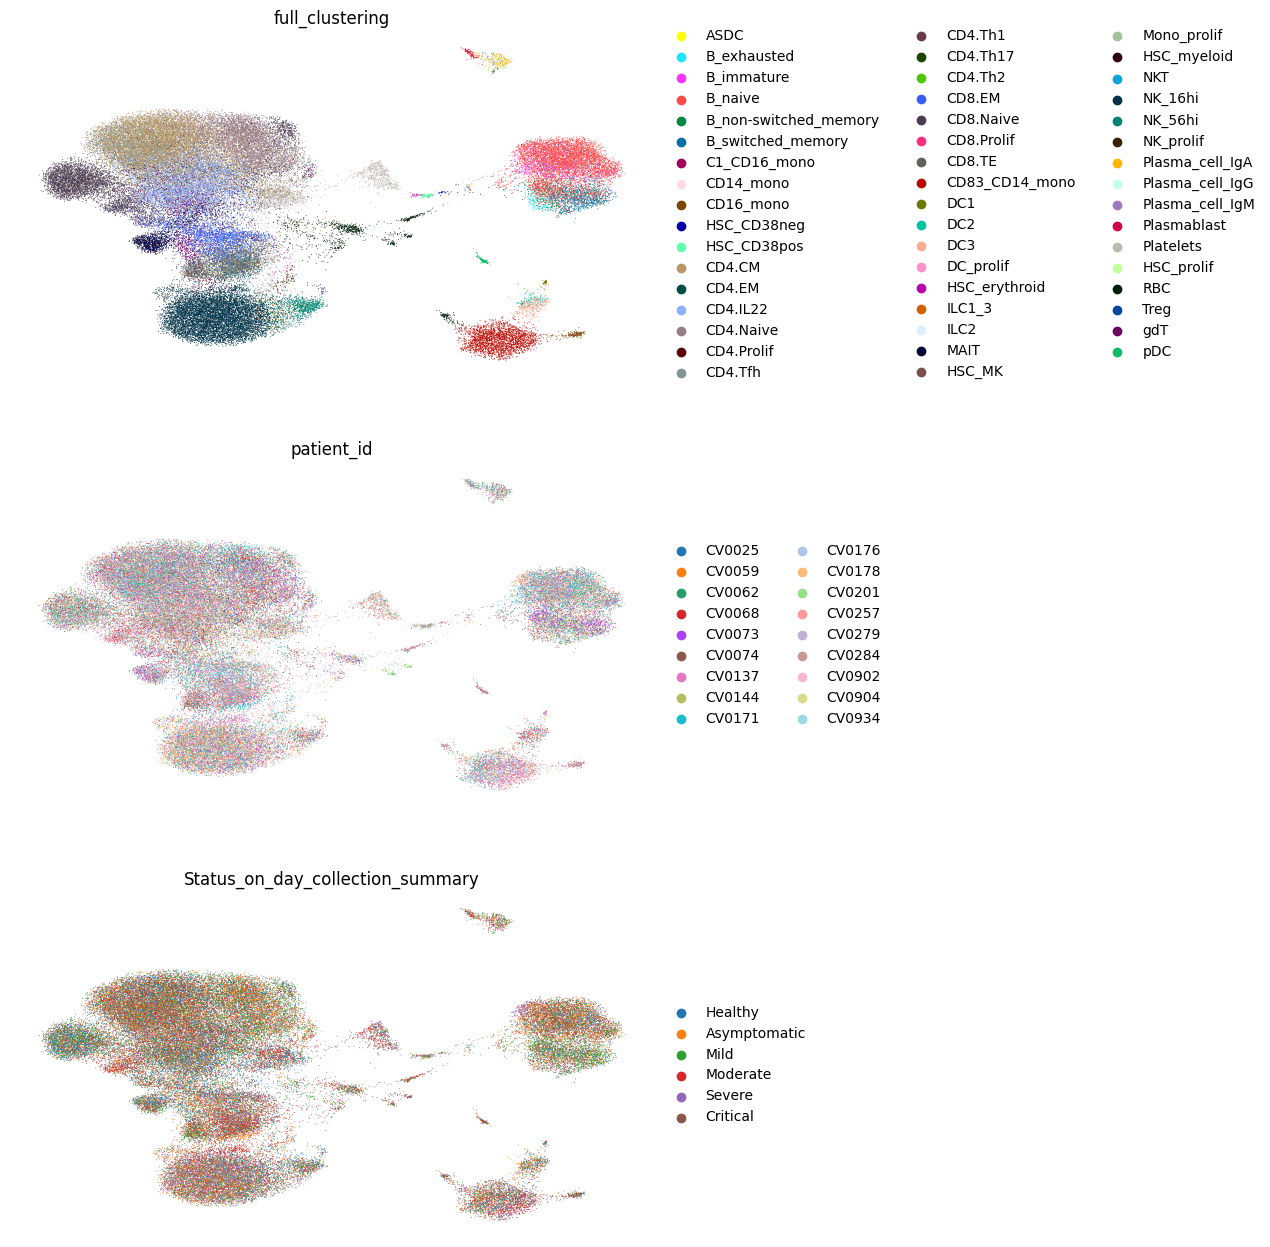

In [6]:
sc.pl.umap(
    adata,
    color=[CELLTYPE_COL, PATIENT_COL, SEVERITY_COL],
    ncols=1, wspace=0.4, frameon=False, show=True,
)

## Step 2 -- Per-latent-dimension association
For each of the 20 dims, fraction of variance explained (eta-squared) by cell type,
patient, and severity. A dim where patient explains more than cell type is carrying
batch/patient identity rather than biology -- flag it.

In [7]:
def eta_squared(x: np.ndarray, groups: pd.Series) -> float:
    """Fraction of variance in continuous x explained by a categorical grouping."""
    df = pd.DataFrame({'x': np.asarray(x, dtype=float), 'g': np.asarray(groups)})
    grand = df['x'].mean()
    ss_total = ((df['x'] - grand) ** 2).sum()
    if ss_total == 0:
        return 0.0
    ss_between = df.groupby('g')['x'].apply(lambda v: len(v) * (v.mean() - grand) ** 2).sum()
    return float(ss_between / ss_total)


Z = adata.obsm['X_totalVI']
factors = {
    'cell_type': adata.obs[CELLTYPE_COL],
    'patient':   adata.obs[PATIENT_COL],
    'severity':  adata.obs[SEVERITY_COL],
}
assoc = pd.DataFrame(
    [{f: eta_squared(Z[:, d], g) for f, g in factors.items()} for d in range(Z.shape[1])]
)
assoc.index.name = 'dim'
assoc['patient_dominated'] = assoc['patient'] > assoc['cell_type']
assoc.round(3)

,cell_type,patient,severity,patient_dominated
dim,,,,
0,0.122,0.003,0.001,False
1,0.330,0.007,0.003,False
2,0.538,0.029,0.010,False
3,0.194,0.004,0.001,False
4,0.054,0.009,0.002,False
5,0.113,0.001,0.000,False
6,0.124,0.004,0.002,False
7,0.729,0.014,0.006,False
8,0.371,0.011,0.003,False


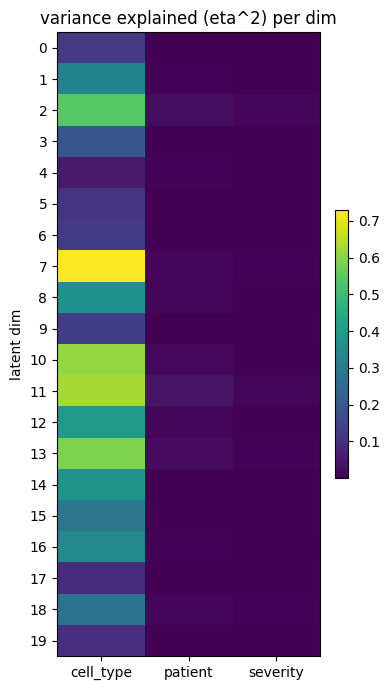

patient-dominated dims: []


In [8]:
fig, ax = plt.subplots(figsize=(4, 7))
im = ax.imshow(assoc[['cell_type', 'patient', 'severity']].values,
               aspect='auto', cmap='viridis')
ax.set_xticks(range(3)); ax.set_xticklabels(['cell_type', 'patient', 'severity'])
ax.set_yticks(range(Z.shape[1])); ax.set_ylabel('latent dim')
ax.set_title('variance explained (eta^2) per dim')
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

print('patient-dominated dims:', assoc.index[assoc['patient_dominated']].tolist())

## Step 3 -- Linear probe for severity (patient-held-out)
Logistic regression from the 20-d latent to severity tier, `GroupKFold` by patient
(never random CV -- that leaks patient identity). Benchmarked against a majority-class
baseline and a single-feature linear deviation-score baseline.

This is a **validation check** on the relationship model, not the study deliverable.

The deviation score below is a self-contained linear matched-pair score (global
protein~RNA fit per pair, per-cell mean |standardized residual|). Swap in
`coupling.deviation_score` here if preferred.

In [12]:
import importlib.util  # load coupling.py the same way nb02 does, BASE_PATH-relative
spec = importlib.util.spec_from_file_location("coupling", str(COUPLING_PATH))
coupling = importlib.util.module_from_spec(spec)
spec.loader.exec_module(coupling)
print("coupling loaded:", [n for n in dir(coupling) if not n.startswith("_")])

coupling loaded: ['Optional', 'coupling_score_by_celltype', 'deviation_score', 'np', 'pd', 'pearsonr', 'per_gene_pearson']


In [14]:
def _dense(a) -> np.ndarray:
    """Dense float32 ndarray from a possibly-sparse matrix/view (mirrors nb03)."""
    return np.asarray(a.todense() if hasattr(a, 'todense') else a, dtype=np.float32)


def clr_normalize(counts: np.ndarray) -> np.ndarray:
    """CLR-normalize ADT counts per cell (log-ratio to per-cell geometric mean). Mirrors nb02."""
    counts = _dense(counts) + 1  # pseudocount, avoid log(0)
    log_counts = np.log(counts)
    return log_counts - log_counts.mean(axis=1, keepdims=True)


def lognorm_rna(counts: np.ndarray) -> np.ndarray:
    """CP10k + log1p, numpy equivalent of nb02's normalize_total(1e4)+log1p."""
    counts = _dense(counts)
    size = counts.sum(axis=1, keepdims=True)
    size[size == 0] = 1.0
    return np.log1p(counts / size * 1e4)


# align matched genes/proteins into the same pair order
pair_proteins = [p for p in adata.uns['protein_names'] if p in adt_to_gene]
pair_genes    = [adt_to_gene[p] for p in pair_proteins]
prot_idx = [list(adata.uns['protein_names']).index(p) for p in pair_proteins]

rna_ln  = lognorm_rna(adata[:, pair_genes].layers['counts'])
prot_cl = clr_normalize(adata.obsm['protein_expression'][:, prot_idx])

# Ridge RNA->protein across pairs, per-cell mean|residual|. Unsupervised w.r.t.
# severity, so safe to fit on all cells before the patient-held-out probe.
adata.obs['deviation_score'] = coupling.deviation_score(rna_ln, prot_cl)
print('deviation_score computed over', len(pair_proteins), 'matched pairs')

deviation_score computed over 163 matched pairs


In [15]:
def grouped_probe(X: np.ndarray, y: np.ndarray, groups: np.ndarray,
                  estimator, n_splits: int = N_SPLITS) -> np.ndarray:
    """Balanced accuracy per fold, patient-held-out, features standardized on train."""
    gkf = GroupKFold(n_splits=n_splits)
    scores = []
    for tr, te in gkf.split(X, y, groups):
        scaler = StandardScaler().fit(X[tr])
        model = clone(estimator).fit(scaler.transform(X[tr]), y[tr])
        scores.append(balanced_accuracy_score(y[te], model.predict(scaler.transform(X[te]))))
    return np.array(scores)


y      = adata.obs[SEVERITY_COL].astype(str).values
groups = adata.obs[PATIENT_COL].values
logreg = LogisticRegression(max_iter=1000, class_weight='balanced')

probes = {
    'majority':       grouped_probe(np.zeros((adata.n_obs, 1)), y, groups,
                                    DummyClassifier(strategy='most_frequent')),
    'deviation (1d)': grouped_probe(adata.obs[['deviation_score']].values, y, groups, logreg),
    'latent (20d)':   grouped_probe(adata.obsm['X_totalVI'], y, groups, logreg),
}
summary = pd.DataFrame({k: [v.mean(), v.std()] for k, v in probes.items()},
                       index=['balanced_acc_mean', 'balanced_acc_std']).T
print('chance level (1/n_tiers):', round(1 / adata.obs[SEVERITY_COL].nunique(), 3))
summary.round(3)

chance level (1/n_tiers): 0.167


,balanced_acc_mean,balanced_acc_std
majority,0.000,0.000
deviation (1d),0.218,0.124
latent (20d),0.170,0.024


## Step 4 -- Reconstruction-based deviation score
Per-cell protein reconstruction error (raw vs `protein_denoised`) as a nonlinear
analog of the linear deviation score. Both are log1p + per-protein z-scored so the
error is on a comparable scale, then reduced to a per-cell RMSE across proteins.
Mapped against severity tier and cell type.

In [16]:
def _z_log(a: np.ndarray) -> np.ndarray:
    """log1p then per-column z-score."""
    a = np.log1p(np.asarray(a, dtype=np.float32))
    return (a - a.mean(0)) / (a.std(0) + 1e-8)


raw = _z_log(adata.obsm['protein_expression'])
den = _z_log(adata.obsm['protein_denoised'])
adata.obs['recon_deviation'] = np.sqrt(((raw - den) ** 2).mean(axis=1))

by_tier = adata.obs.groupby(SEVERITY_COL, observed=True)['recon_deviation'].mean()
by_ct   = adata.obs.groupby(CELLTYPE_COL, observed=True)['recon_deviation'].mean().sort_values()
print('recon_deviation by severity tier:\n', by_tier.round(4))
print('\nrecon_deviation by cell type (sorted):\n', by_ct.round(4))

recon_deviation by severity tier:
 Status_on_day_collection_summary
Healthy         0.6388
Asymptomatic    0.6057
Mild            0.6134
Moderate        0.6112
Severe          0.6321
Critical        0.5919
Name: recon_deviation, dtype: float32

recon_deviation by cell type (sorted):
 full_clustering
CD4.Tfh                  0.5820
HSC_prolif               0.5921
CD4.CM                   0.5982
CD4.EM                   0.6019
CD8.Naive                0.6040
CD4.Th1                  0.6083
CD4.Naive                0.6084
CD8.TE                   0.6105
CD4.Th2                  0.6113
Treg                     0.6115
Platelets                0.6161
RBC                      0.6162
CD4.Th17                 0.6166
CD4.IL22                 0.6182
NKT                      0.6194
B_naive                  0.6199
gdT                      0.6208
B_immature               0.6233
CD8.EM                   0.6238
MAIT                     0.6250
CD14_mono                0.6251
NK_16hi                  0.

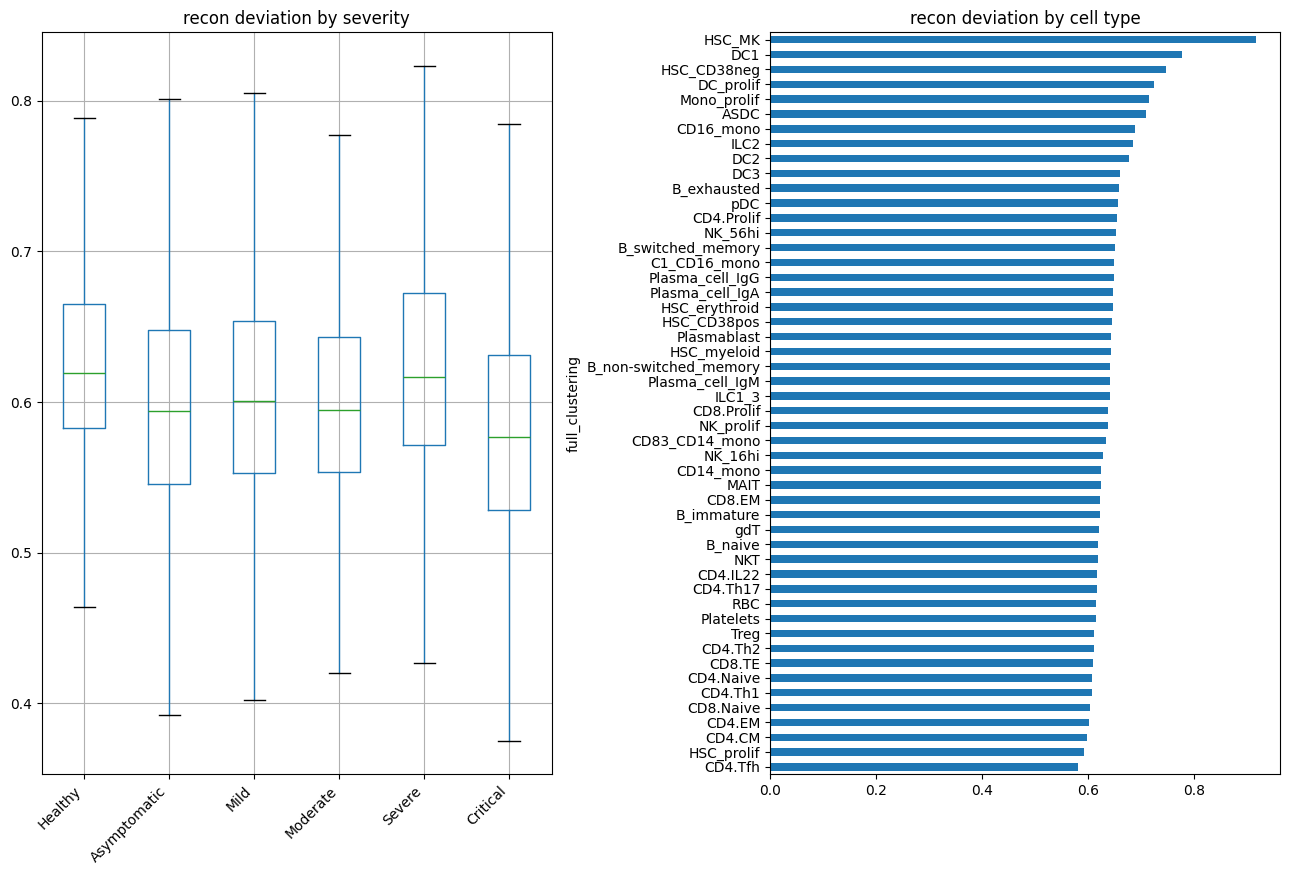

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 9))
order = [t for t in TIER_ORDER if t in adata.obs[SEVERITY_COL].cat.categories]
adata.obs.boxplot(column='recon_deviation', by=SEVERITY_COL, ax=axes[0],
                  positions=range(len(order)), showfliers=False)
axes[0].set_title('recon deviation by severity'); axes[0].set_xlabel(''); axes[0].set_xticklabels(order, rotation=45, ha='right')
by_ct.plot(kind='barh', ax=axes[1]); axes[1].set_title('recon deviation by cell type')
plt.suptitle(''); plt.tight_layout(); plt.show()

### Step 4 guardrail -- is any tier signal just one patient?
Repeat the CV0178-style diagnostic: per-patient mean within each tier. Do not report
a tier-level trend that collapses to a single patient (n=3/tier).

In [21]:
per_pt = (adata.obs.groupby([SEVERITY_COL, PATIENT_COL], observed=True)['recon_deviation']
          .mean().dropna().reset_index())
per_pt['is_known_confound'] = per_pt[PATIENT_COL] == KNOWN_CONFOUND_PATIENT
print(per_pt.sort_values([SEVERITY_COL, 'recon_deviation'], ascending=[True, False]).to_string(index=False))

Status_on_day_collection_summary patient_id  recon_deviation  is_known_confound
                         Healthy     CV0934         0.660327              False
                         Healthy     CV0902         0.640145              False
                         Healthy     CV0904         0.627345              False
                    Asymptomatic     CV0059         0.616237              False
                    Asymptomatic     CV0068         0.615110              False
                    Asymptomatic     CV0171         0.590951              False
                            Mild     CV0073         0.635382              False
                            Mild     CV0074         0.628071              False
                            Mild     CV0062         0.574414              False
                        Moderate     CV0025         0.631489              False
                        Moderate     CV0137         0.616163              False
                        Moderate     CV0

## Step 5 -- Pathway discovery
For each matched protein, correlate its denoised expression against **all** genes in
the union (not just its 1:1 partner), across cells. Genes beyond the matched pair that
still track the protein are pathway-member candidates -- the actual answer to
"what else drives this protein". Matched gene is excluded from each protein's list.

In [22]:
def corr_all(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    """Column-wise Pearson correlation between every column of A and every column of B."""
    Az = (A - A.mean(0)) / (A.std(0) + 1e-8)
    Bz = (B - B.mean(0)) / (B.std(0) + 1e-8)
    return (Az.T @ Bz) / A.shape[0]


rna  = np.asarray(adata.layers['totalVI_normalized'], dtype=np.float32)  # (cells, genes)
prot = np.asarray(adata.obsm['protein_denoised'], dtype=np.float32)      # (cells, proteins)
genes    = adata.var_names.to_numpy()
proteins = np.asarray(adata.uns['protein_names'])

C = corr_all(rna, prot)  # (genes, proteins)
print('correlation matrix:', C.shape)

correlation matrix: (2092, 163)


In [23]:
records = []
for j, protein in enumerate(proteins):
    matched = adt_to_gene.get(protein)
    order = np.argsort(-np.abs(C[:, j]))
    kept = 0
    for gi in order:
        gene = genes[gi]
        if gene == matched:
            continue
        records.append({'protein': protein, 'matched_gene': matched,
                        'candidate_gene': gene, 'r': float(C[gi, j])})
        kept += 1
        if kept >= TOP_K_GENES:
            break

pathway = pd.DataFrame(records)
out = RESULTS_TABLES / 'nb04_pathway_candidates.csv'
pathway.to_csv(out, index=False)
print('saved', out, '|', pathway.shape)

saved /content/drive/MyDrive/covid_citeseq_project/results/tables/nb04_pathway_candidates.csv | (2445, 4)


In [24]:
# spot-check: top candidates for a few proteins
example_proteins = list(proteins[:3]) + [p for p in ['CD8', 'CD19'] if p in set(proteins)]
for p in dict.fromkeys(example_proteins):
    top = pathway[pathway['protein'] == p].head(6)
    print(f"\n{p} (matched: {adt_to_gene.get(p)})")
    print(top[['candidate_gene', 'r']].to_string(index=False))


AB_CD80 (matched: CD80)
candidate_gene        r
         KRT80 0.468920
         IGLC4 0.408150
        CLDN14 0.302211
      Z98257.1 0.299266
    AC141272.1 0.294948
    FP700111.1 0.256118

AB_CD86 (matched: CD86)
candidate_gene        r
         PLAUR 0.485377
    AC015912.3 0.468554
        CLEC7A 0.467018
         IL1RN 0.458079
         IFI30 0.454626
         IGSF6 0.453841

AB_CD274 (matched: CD274)
candidate_gene        r
         KRT80 0.453589
         IGLC4 0.370845
      Z98257.1 0.288006
    AC141272.1 0.282573
        CLDN14 0.275037
    FP700111.1 0.251574


## Notes for write-up
- Step 1 is a gate: no clean cell-type separation -> stop, the latent isn't biology.
- Step 3 probe accuracy is a validation number, not the result. Read it against the
  majority and deviation baselines, not in isolation.
- Any severity trend in Steps 3/4 must survive the Step-4 per-patient breakdown
  (CV0178) before it's reported.
- Step 5 candidates are correlational only; treat as hypotheses for follow-up.